### LIBRERÍAS

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [27]:
df = pd.read_csv('data/transacciones_supermercado.csv')
df.head(5)

,line_id,ticket_number,user_card_id,payment_method,shop_name,shop_address,product_code,product_name,seccion,units,price_per_unit,price_total,created_at
0,9521661,6566575,100758,EFECTIVO,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1057,CHAMPU ANTICASPA 400ML,Higiene,1,3.11,3.11,2025-01-24 20:24
1,9521662,6566575,100758,EFECTIVO,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1028,YOGUR NATURAL PACK 4,Lacteos,1,1.51,1.51,2025-01-24 20:24
2,9521663,6566575,100758,EFECTIVO,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1029,QUESO RALLADO 200G,Lacteos,1,2.38,2.38,2025-01-24 20:24
3,9521664,6566575,100758,EFECTIVO,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1035,REFRESCO NARANJA 2L,Bebidas,1,1.77,1.77,2025-01-24 20:24
4,9521665,6566575,100758,EFECTIVO,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1038,ZUMO NARANJA 1L,Bebidas,1,1.66,1.66,2025-01-24 20:24


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   line_id         50000 non-null  int64  
 1   ticket_number   50000 non-null  int64  
 2   user_card_id    50000 non-null  int64  
 3   payment_method  50000 non-null  object 
 4   shop_name       50000 non-null  object 
 5   shop_address    50000 non-null  object 
 6   product_code    50000 non-null  int64  
 7   product_name    50000 non-null  object 
 8   seccion         50000 non-null  object 
 9   units           50000 non-null  int64  
 10  price_per_unit  50000 non-null  float64
 11  price_total     50000 non-null  float64
 12  created_at      50000 non-null  object 
dtypes: float64(2), int64(5), object(6)
memory usage: 5.0+ MB


In [4]:
# modificamos columna created_at para pasar de object a datetime
df['created_at'] = pd.to_datetime(df['created_at'], format='%Y-%m-%d %H:%M')
df

,line_id,ticket_number,user_card_id,payment_method,shop_name,shop_address,product_code,product_name,seccion,units,price_per_unit,price_total,created_at
0,9521661,6566575,100758,EFECTIVO,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1057,CHAMPU ANTICASPA 400ML,Higiene,1,3.11,3.11,2025-01-24 20:24:00
1,9521662,6566575,100758,EFECTIVO,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1028,YOGUR NATURAL PACK 4,Lacteos,1,1.51,1.51,2025-01-24 20:24:00
2,9521663,6566575,100758,EFECTIVO,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1029,QUESO RALLADO 200G,Lacteos,1,2.38,2.38,2025-01-24 20:24:00
3,9521664,6566575,100758,EFECTIVO,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1035,REFRESCO NARANJA 2L,Bebidas,1,1.77,1.77,2025-01-24 20:24:00
4,9521665,6566575,100758,EFECTIVO,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1038,ZUMO NARANJA 1L,Bebidas,1,1.66,1.66,2025-01-24 20:24:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,9571656,6571769,100437,TARJETA,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1018,LECHUGA ICEBERG UD,Frescos,1,0.93,0.93,2025-06-20 21:07:00
49996,9571657,6571769,100437,TARJETA,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1020,CEBOLLA KG,Frescos,1,1.05,1.05,2025-06-20 21:07:00
49997,9571658,6571769,100437,TARJETA,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1022,CARNE PICADA MIXTA 500G,Frescos,1,3.93,3.93,2025-06-20 21:07:00
49998,9571659,6571770,100024,TARJETA,Carrefour Vigo Coia,"Av. de Citroën 116, Vigo",1057,CHAMPU ANTICASPA 400ML,Higiene,1,3.04,3.04,2025-01-22 12:50:00


In [5]:
df = df.sort_values('created_at').reset_index(drop=True) # reniciamos índice para que no se cree una columna.
print(df["created_at"].is_monotonic_increasing) #comprobación de que todo funciona bien
df.head(9)

True


,line_id,ticket_number,user_card_id,payment_method,shop_name,shop_address,product_code,product_name,seccion,units,price_per_unit,price_total,created_at
0,9550698,6569586,100552,EFECTIVO,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1041,HELADO VAINILLA 1L,Congelados,1,3.41,3.41,2025-01-01 08:20:00
1,9550697,6569586,100552,EFECTIVO,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1008,AZUCAR BLANCO 1KG,Alimentacion seca,1,1.06,1.06,2025-01-01 08:20:00
2,9550707,6569586,100552,EFECTIVO,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1055,BOLSAS BASURA 30L,Drogueria,1,1.98,1.98,2025-01-01 08:20:00
3,9550706,6569586,100552,EFECTIVO,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1022,CARNE PICADA MIXTA 500G,Frescos,1,3.95,3.95,2025-01-01 08:20:00
4,9550693,6569586,100552,EFECTIVO,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1068,ARENA GATO 5L,Mascotas,2,3.94,7.88,2025-01-01 08:20:00
5,9550692,6569586,100552,EFECTIVO,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1003,ARROZ REDONDO 1KG,Alimentacion seca,1,1.38,1.38,2025-01-01 08:20:00
6,9550691,6569586,100552,EFECTIVO,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1028,YOGUR NATURAL PACK 4,Lacteos,1,1.43,1.43,2025-01-01 08:20:00
7,9550690,6569586,100552,EFECTIVO,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1057,CHAMPU ANTICASPA 400ML,Higiene,1,3.20,3.20,2025-01-01 08:20:00
8,9550705,6569586,100552,EFECTIVO,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1021,PECHUGA POLLO BANDEJA,Frescos,2,4.93,9.86,2025-01-01 08:20:00


### Análisis a nivel TICKET

In [6]:
# productos por ticket
productos_ticket = df.groupby('ticket_number').size()

# valor por ticket
valor_ticket = df.groupby('ticket_number')['price_total'].sum().round(2)

In [7]:
print('Productos por ticket')
productos_ticket.describe()

Productos por ticket


count    5196.000000
mean        9.622787
std         5.220613
min         1.000000
25%         6.000000
50%         9.000000
75%        13.000000
max        43.000000
dtype: float64

In [8]:
print('Valor por ticket (€)')
valor_ticket.describe()

Valor por ticket (€)


count    5196.000000
mean       41.123276
std        27.245658
min         0.910000
25%        21.047500
50%        35.195000
75%        56.312500
max       197.840000
Name: price_total, dtype: float64

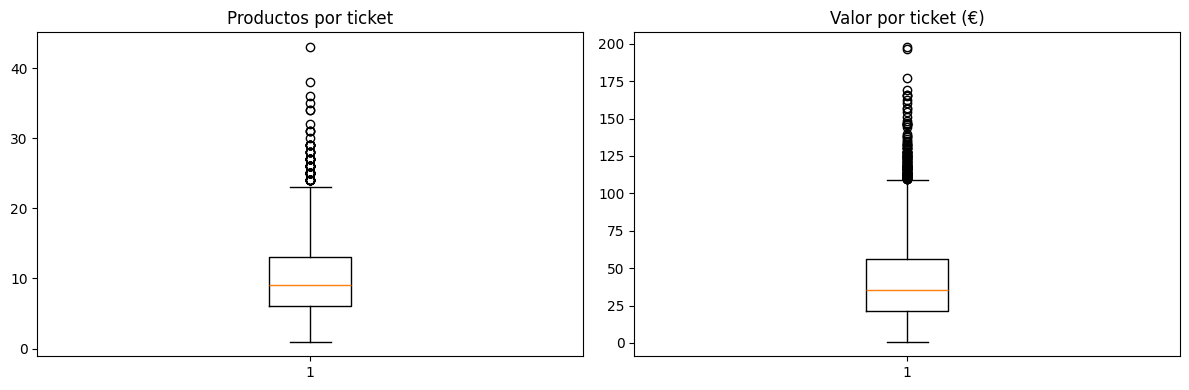

In [9]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].boxplot(productos_ticket)
ax[0].set_title('Productos por ticket')

ax[1].boxplot(valor_ticket)
ax[1].set_title('Valor por ticket (€)')
plt.tight_layout()
plt.show()

KPI ticket
Ticket medio (€): 41.12
Ticket mediano (€): 35.20
Productos medios/ticket: 9.6
Productos medianos/ticket: 9


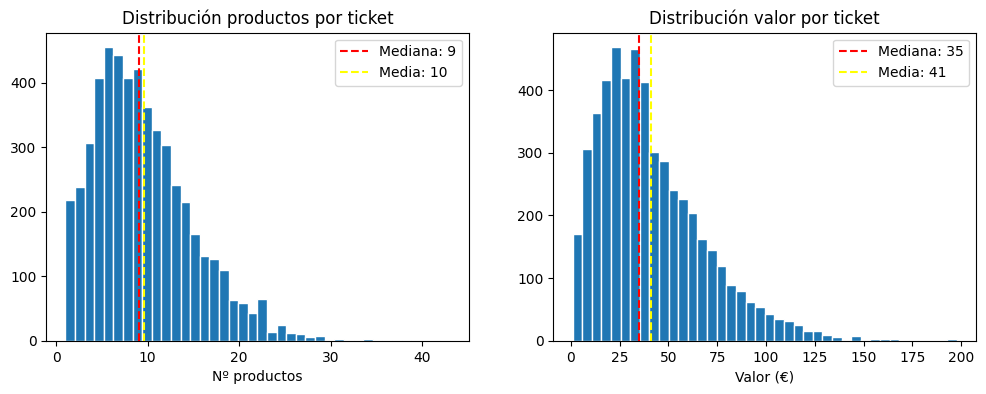

In [10]:
print('KPI ticket')
print(f'Ticket medio (€): {valor_ticket.mean():.2f}')
print(f'Ticket mediano (€): {valor_ticket.median():.2f}')
print(f'Productos medios/ticket: {productos_ticket.mean():.1f}')
print(f'Productos medianos/ticket: {productos_ticket.median():.0f}')

fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].hist(productos_ticket, bins=40,edgecolor='white')
ax[0].axvline(productos_ticket.median(), color='red', ls='--', label=f'Mediana: {productos_ticket.median():.0f}')
ax[0].axvline(productos_ticket.mean(), color='yellow', ls='--', label=f'Media: {productos_ticket.mean():.0f}')
ax[0].set_title('Distribución productos por ticket')
ax[0].set_xlabel('Nº productos')
ax[0].legend()

ax[1].hist(valor_ticket, bins=40, edgecolor='white')
ax[1].axvline(valor_ticket.median(), color='red', ls='--', label=f'Mediana: {valor_ticket.median():.0f}')
ax[1].axvline(valor_ticket.mean(), color='yellow', ls='--', label=f'Media: {valor_ticket.mean():.0f}')
ax[1].set_title('Distribución valor por ticket')
ax[1].set_xlabel('Valor (€)')
ax[1].legend()
plt.show()

Observando el comportamiento del ticket, se puede ver como el gasto medio es superior al mediano. Esta brecha se debe a que el ticket medio se encuentra inflado por compras grandes, mientras que el ticket mediano representa más la realidad del cliente habitual.

En cuanto al número de productos, el tamaño de la cesta resulta más homogéneo. La principal diferencia es que mientras el ticket se ve afectado por precio y cantidad, aquí solo afecta la cantidad de productos en la cesta. 

Los diagramas de cajas ayudan a visualizar la presencia de estos valores atípicos y principalmente en el valor de ticket, cómo estos mismos tiran de la media hacia arriba, no siendo así con el comportamiento del número de productos por ticket.

Los histogramas indican que estamos ante distribuciones NO normales para los productos por ticket y el valor del mismo. Presentan una asimetría positiva hacia la derecha.

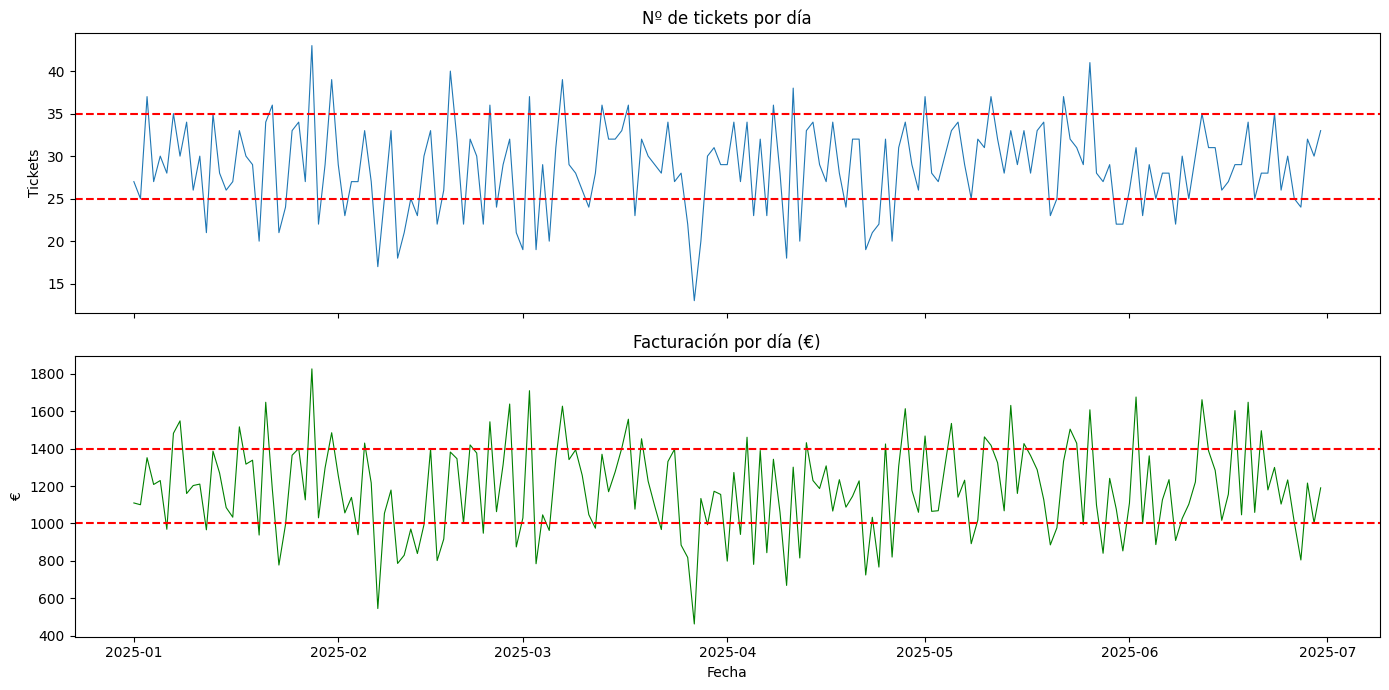

In [11]:
# Volumen de tickets por día
ventas_diarias = df.groupby(df["created_at"].dt.date)["ticket_number"].nunique()

# Volumen de facturación por día
facturacion_diaria = df.groupby(df["created_at"].dt.date)["price_total"].sum()

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax[0].plot(ventas_diarias.index, ventas_diarias.values, linewidth=0.8)
ax[0].axhline(y=35, color='r', ls='--')
ax[0].axhline(y=25, color='r', ls='--')
ax[0].set_title("Nº de tickets por día")
ax[0].set_ylabel("Tickets")

ax[1].plot(facturacion_diaria.index, facturacion_diaria.values, linewidth=0.8, color="green")
ax[1].set_title("Facturación por día (€)")
ax[1].axhline(y=1400, color='r', ls='--')
ax[1].axhline(y=1000, color='r', ls='--')
ax[1].set_ylabel("€")
ax[1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

Observando el comportamiento a lo largo del tiempo, se puede apreciar una estabilidad en las compras. Para el número de tickets por día, la estabilidad se encuentra en el rango de 25-35 tickets. En cuanto a la facturación diaria, se observa la estabilidad entre 1000 y 1400€ por día.

Esta estabilidad, a la hora de separar los conjuntos en train/test devolverá conjuntos de volumen comparables, sin sesgos estacionales.

### Análisis a nivel CLIENTE

In [12]:
# Tickets por cliente (recurrencia)
tickets_cliente = df.groupby("user_card_id")["ticket_number"].nunique() # nunique para obtener valor único.

# Productos DISTINTOS por cliente
productos_distintos = df.groupby("user_card_id")["product_code"].nunique()

# Gasto total por cliente
gasto_cliente = df.groupby("user_card_id")["price_total"].sum()

In [13]:
print("Tickets por cliente")
tickets_cliente.describe()

Tickets por cliente


count    1342.000000
mean        3.871833
std         2.857015
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        19.000000
Name: ticket_number, dtype: float64

Uno de los problemas que se encuentran en los sistemas de recomendación es el efecto llamado cold start. El cold start se da cuando tenemos un cliente nuevo que apenas tiene registros o cuando buscamos introducir un nuevo producto. En estos casos si no se plantea de forma correcta, el sistema tiende a ignorar la recomendación de esos productos. 

Vamos a buscar el nº de clientes que tienen un solo ticket y pueden generar problemas

In [14]:
print(f'Clientes con 1 ticket (cold start): {(tickets_cliente == 1).sum()}')

Clientes con 1 ticket (cold start): 261


In [15]:
print("Productos distintos por cliente")
productos_distintos.describe()

Productos distintos por cliente


count    1342.000000
mean       21.973174
std        10.975637
min         1.000000
25%        13.000000
50%        21.000000
75%        30.000000
max        53.000000
Name: product_code, dtype: float64

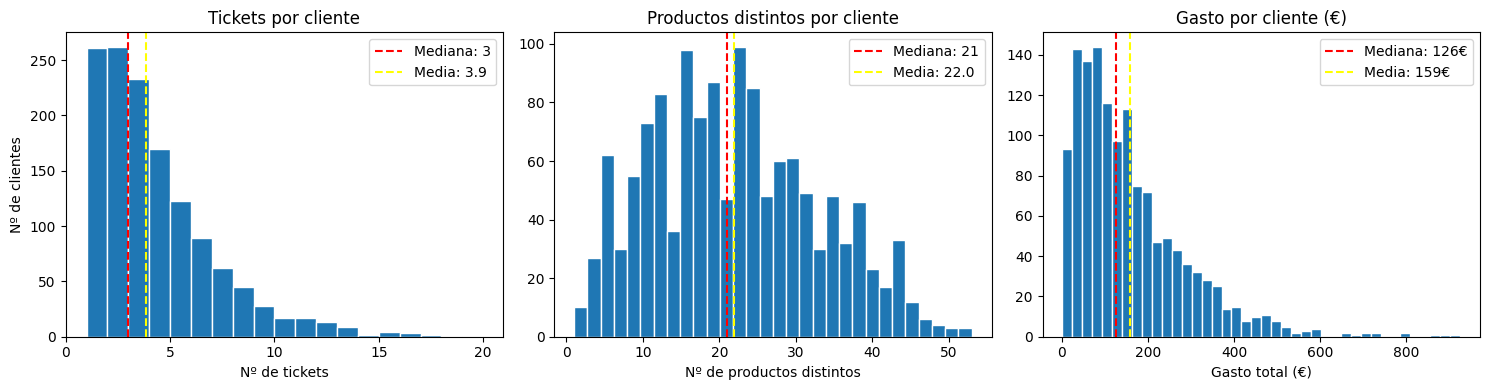

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(tickets_cliente, bins=range(1, tickets_cliente.max()+2), edgecolor='white')
ax[0].set_title("Tickets por cliente")
ax[0].axvline(tickets_cliente.median(), color="red", linestyle="--", label=f"Mediana: {tickets_cliente.median():.0f}")
ax[0].axvline(tickets_cliente.mean(), color="yellow", linestyle="--", label=f"Media: {tickets_cliente.mean():.1f}")
ax[0].set_title("Tickets por cliente")
ax[0].set_xlabel("Nº de tickets")
ax[0].set_xticks(range(0, int(tickets_cliente.max()) + 5, 5))
ax[0].set_ylabel("Nº de clientes")
ax[0].legend()

ax[1].hist(productos_distintos, bins=30, edgecolor='white')
ax[1].axvline(productos_distintos.median(), color="red", linestyle="--", label=f"Mediana: {productos_distintos.median():.0f}")
ax[1].axvline(productos_distintos.mean(), color="yellow", linestyle="--", label=f"Media: {productos_distintos.mean():.1f}")
ax[1].set_title("Productos distintos por cliente")
ax[1].set_xlabel("Nº de productos distintos")
ax[1].legend()

ax[2].hist(gasto_cliente, bins=40, edgecolor='white')
ax[2].axvline(gasto_cliente.median(), color="red", linestyle="--", label=f"Mediana: {gasto_cliente.median():.0f}€")
ax[2].axvline(gasto_cliente.mean(), color="yellow", linestyle="--", label=f"Media: {gasto_cliente.mean():.0f}€")
ax[2].set_title("Gasto por cliente (€)")
ax[2].set_xlabel("Gasto total (€)")

ax[2].legend()

plt.tight_layout()
plt.show()

Observando los ticket por cliente, el grueso se concentra entre 1 y 5 tickets con una cola asimétrica hacia la derecha. Cuanto más a la derecha, concluímos que tenemos una mayor fidelidad del cliente. En este caso la conclusión es que la mayoría son compradores ocasionales.

En cuanto a al nivel de productos distintos que ha comprado cada cliente, presenta cierta simetría, llegando a crear una pequeña campana alrededor de la mediana aunque de forma irregular. Esta situación es favorable para la construcción del sistema de recomendación debido a la variedad de productos comprados.

Finalmente, el gasto por cliente vuelve a presentar una asimetría positiva hacia la derecha. La mayoría de clientes, como se puede intuir con la frecuencia de tickets por cliente, tienen poco gasto. Se puede apreciar un segmento de clientes que presentan un gasto elevado, clientes muy fidelizados.

In [17]:
n_clientes = df['user_card_id'].nunique()
n_productos = df['product_code'].nunique()
interacciones = df.groupby(['user_card_id', 'product_code']).ngroups

densidad = interacciones / (n_clientes * n_productos)

print(f"Clientes:              {n_clientes}")
print(f"Productos:             {n_productos}")
print(f"Interacciones únicas:  {interacciones}")
print(f"Celdas totales:        {n_clientes * n_productos}")
print(f"Densidad de la matriz: {densidad*100:.2f}%")
print(f"Sparsity (vacío):      {(1-densidad)*100:.2f}%")

Clientes:              1342
Productos:             68
Interacciones únicas:  29488
Celdas totales:        91256
Densidad de la matriz: 32.31%
Sparsity (vacío):      67.69%


Se constrye una matriz de densidad cliente-producto para tener una idea previa de como se comportan los clientes. La densidad está enfocada a construir un sistema ALS que permite conocer el perfil de un cliente a largo plazo. En este proyecto, la densidad es alta debido al reducido tamaño del dataset. Si se tratase de un proyecto real, es importante matizar que lo más probable es que la densidad de la matriz no alcance ni un 5%.

### Análisis a nivel PRODUCTO y SECCION

In [18]:
# Frecuencia de cada producto
ventas_producto = df.groupby("product_name").size().sort_values(ascending=False)
pct_producto = (ventas_producto / ventas_producto.sum()*100).round(2)
print("TOP 10 productos más vendidos")
print(ventas_producto.head(10))
print('-'*50)
print('Top 10 productos en %')
print(pct_producto.head(10))

TOP 10 productos más vendidos
product_name
CHAMPU ANTICASPA 400ML      4074
LECHUGA ICEBERG UD          3387
YOGUR NATURAL PACK 4        2705
HELADO VAINILLA 1L          2221
ARROZ REDONDO 1KG           1951
TOMATE RAMA KG              1931
ENSALADA CESAR PREPARADA    1588
CERVEZA PACK 6              1521
SAL FINA 1KG                1346
PAPILLA CEREALES 600G       1282
dtype: int64
--------------------------------------------------
Top 10 productos en %
product_name
CHAMPU ANTICASPA 400ML      8.15
LECHUGA ICEBERG UD          6.77
YOGUR NATURAL PACK 4        5.41
HELADO VAINILLA 1L          4.44
ARROZ REDONDO 1KG           3.90
TOMATE RAMA KG              3.86
ENSALADA CESAR PREPARADA    3.18
CERVEZA PACK 6              3.04
SAL FINA 1KG                2.69
PAPILLA CEREALES 600G       2.56
dtype: float64


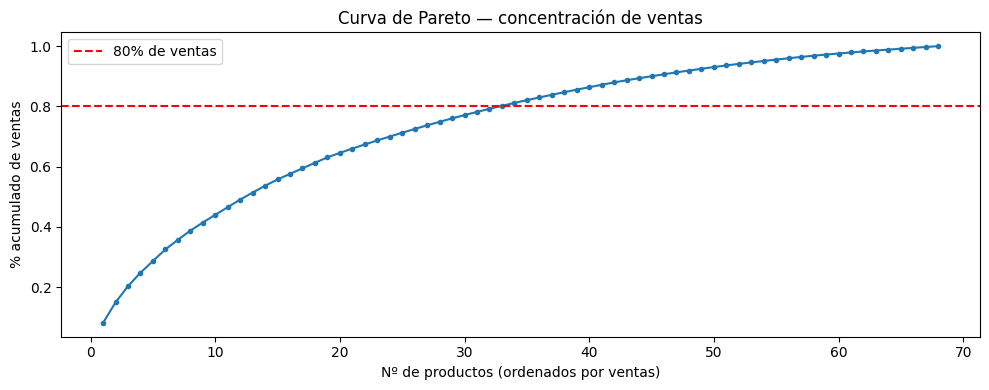

In [19]:
# Curva de Pareto
pareto_producto = ventas_producto.cumsum() / ventas_producto.sum()

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(pareto_producto)+1), pareto_producto.values, marker=".")
plt.axhline(0.8, color="red", linestyle="--", label="80% de ventas")
plt.xlabel("Nº de productos (ordenados por ventas)")
plt.ylabel("% acumulado de ventas")
plt.title("Curva de Pareto — concentración de ventas")
plt.legend()
plt.tight_layout()
plt.show()

Pareto indica que el 20% de los productos representa el 80% de las ventas. En este escenario, dado que los datos son sintéticos, las ventas se distribuyen de forma equitativa. Este comportamiento lleva a que se necesita alrdedor del 50% de los productos para lograr el 80% de las ventas, es decir, no se cumple pareto. Al igual que en los análisis anteriores, este tipo de situaciones se dan a raíz del tamaño del dataset. 

Un dato a tener en cuenta es que el producto más vendido es el champú anticaspa, en un escenario real, cabe esperar que el producto más vendido sea un algún producto que pertenezca a la categoría de alimentos.



In [20]:
ventas_seccion = df.groupby('seccion').size().sort_values(ascending=False)

pct_seccion = (ventas_seccion / ventas_seccion.sum()*100).round(2)
print("TOP sección más vendida")
print(ventas_seccion)
print('-'*50)
print('Top sección en %')
print(pct_seccion)

TOP sección más vendida
seccion
Frescos              9405
Alimentacion seca    8533
Lacteos              5561
Bebe                 5431
Higiene              4839
Bebidas              4777
Precocinados         4183
Congelados           3288
Drogueria            2095
Mascotas             1888
dtype: int64
--------------------------------------------------
Top sección en %
seccion
Frescos              18.81
Alimentacion seca    17.07
Lacteos              11.12
Bebe                 10.86
Higiene               9.68
Bebidas               9.55
Precocinados          8.37
Congelados            6.58
Drogueria             4.19
Mascotas              3.78
dtype: float64


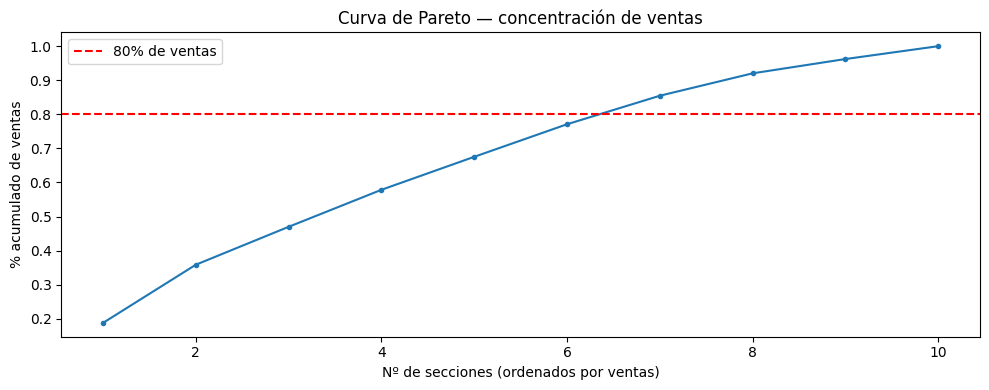

In [21]:
# Curva de Pareto
pareto_seccion = ventas_seccion.cumsum() / ventas_seccion.sum()

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(pareto_seccion)+1), pareto_seccion.values, marker=".")
plt.axhline(0.8, color="red", linestyle="--", label="80% de ventas")
plt.xlabel("Nº de secciones (ordenados por ventas)")
plt.ylabel("% acumulado de ventas")
plt.title("Curva de Pareto — concentración de ventas")
plt.legend()
plt.tight_layout()
plt.show()

Observando el comportamiento de las secciones, esta ya es más realista, en donde las categorías que destacan son productos frescos, alimenticios o lacteos.
En el gráfico de Pareto la curva es más pronunciada, en donde las categorías reina representan casi el 50% de las ventas.

In [ ]:
# pasamos df a pickle para no tener que volver a cambiar campo fecha a datetime en otro notebook
df.to_pickle("data/transacciones_limpio.pkl")